In [ ]:
from config import MODEL_CONFIGS
from pathlib import Path
import pandas as pd
from datasets import Dataset
import json
from transformers import AutoTokenizer
from patching import remove_comments, apply_diff_patch
from tqdm import tqdm
import re
from difflib import SequenceMatcher

WORK_DIR = Path.cwd()
DS_TEST_PATH = WORK_DIR / "dataset" / "split" / "test_dataset.jsonl"
ds_test = Dataset.from_pandas(pd.read_json(DS_TEST_PATH, lines=True))
id_to_idx = {item['id']: idx for idx, item in enumerate(ds_test)}


def extract_code_blocks(text: str) -> list[str]:
    return re.findall(r'```(?:\w+\n?)?(.*?)```', text, re.DOTALL)

def get_code_similarity(good_code: str, fixed_code: str, remove_indents: bool=False) -> float:

    fixed_code = remove_comments(fixed_code)
    good_code = remove_comments(good_code) 

    return SequenceMatcher(None, good_code, fixed_code).ratio()

def compute_similarity(example: dict, result: dict, test_type: str):

    blocks = extract_code_blocks(result["answer"])
    st = False

    if test_type == "fine_tuned_patch": 
        if example["mutation_category"] == "none":
            sim = 1.0 if not blocks else 0.0
            
        else:
            # model is fine tuned to output patch
            patch = blocks[-1] if blocks else ""
            bad_code = example["bad_code"]
            fixed_code, st = apply_diff_patch(bad_code, patch)
            good_code = example["good_code"]
            sim = get_code_similarity(good_code, fixed_code)

    else: 
        # model will give full repaired code
        st = False
        if example["mutation_category"] == "none":
            sim = 1.0 if not blocks else 0.0
        else:
            good_code = example["good_code"]
            fixed_code = blocks[-1] # assume last block is fixed code
            sim = get_code_similarity(good_code, fixed_code)

    return sim, st


def present_results(model: str, test_type: str, always_compute: bool = False):

    if model not in MODEL_CONFIGS:
        raise ValueError(
            f"Unknown model '{model}'. "
            f"Available models: {list(MODEL_CONFIGS.keys())}"
        )

    cfg = MODEL_CONFIGS[model]
    model_name = cfg["model_name"]
    model_short = model_name.split("/")[1]
        
    RESULTS_DIR = WORK_DIR / "results" / "testing" / model_short / test_type / "test_results.json"
    

    # Load results
    with open(RESULTS_DIR) as f:
        results = json.load(f)

    doms, syns, nones, toks = [], [], [], []

    editing = False
    tokenizer = None

    pbar = tqdm(results, desc="Computing results")

    passed_sum = 0
    passed_count = 0
    failed_to_apply = 0
    
    for result in pbar:
        id = result["id"]
        answer = result["answer"]
        idx = id_to_idx[id]
        category = ds_test[idx]["mutation_category"]
        mut_type = ds_test[idx]["mutation_type"]

        passed = result.get("passed", None)
        token_len = result.get("token_len", None)

        if always_compute or passed is None:
            if not editing:
                editing = True

            sim, st = compute_similarity(ds_test[idx], result, test_type)
            if st:
                failed_to_apply += 1
            passed = 1 if sim == 1.0 else 0

            result["mutation_category"] = category
            result["mutation_type"] = mut_type
            result["similarity"] = sim
            result["passed"] = passed

        if always_compute or token_len is None:
            if not editing:
                editing = True

            if tokenizer is None:
                tokenizer = AutoTokenizer.from_pretrained(
                    model_name, trust_remote_code=True
                )

            token_len = len(tokenizer.encode(answer, add_special_tokens=True))
            result["token_len"] = token_len

        toks.append(token_len)

        if passed is not None:
            passed_sum += passed
            passed_count += 1
            pbar.set_postfix(
                last=passed,
                avg=round(passed_sum / passed_count, 4)
        )

        if category == "domain":
            doms.append(passed)
        elif category == "syntax":
            syns.append(passed)
        elif category == "none":
            nones.append(passed)

    dom_score = sum(doms) / len(doms) if len(doms) != 0 else None
    syn_score = sum(syns) / len(syns) if len(syns) != 0 else None
    none_score = sum(nones) / len(nones) if len(nones) != 0 else None

    if dom_score and syn_score and none_score:
        overall_score = (dom_score*len(doms)+syn_score*len(syns)+none_score*len(nones))/(len(doms)+len(syns)+len(nones))
    else:
        overall_score = None

    tok_len_avg = int(sum(toks) / len(toks))

    print(f"Performance for {model_short}, {test_type}:")
    print(f"Syntax: {syn_score} (n={len(syns)})")
    print(f"Domain: {dom_score} (n={len(doms)})")
    print(f"Correct: {none_score} (n={len(nones)})")
    print(f"Overall: {overall_score}")
    print(f"Avg Generated Tokens: {tok_len_avg}\n")
    print(f"Patches failed to be applied: {failed_to_apply}")

    if editing:
        with open(RESULTS_DIR, 'w') as f:
            json.dump(results, f, indent=2)

In [ ]:
present_results(model="deepseek_coder_6p7b", test_type="baseline", always_compute=True)

In [10]:
present_results(model="deepseek_coder_6p7b", test_type="rag_only", always_compute=True)

Computing results: 100%|██████████| 368/368 [00:02<00:00, 176.29it/s, avg=0.0163, last=0]

Performance for deepseek-coder-6.7b-instruct, rag_only:
Syntax: None (n=0)
Domain: 0.0 (n=162)
Correct: 0.02912621359223301 (n=206)
Overall: None
Avg Generated Tokens: 388

Patches failed to be applied: 0


In [8]:
present_results(model="deepseek_coder_6p7b", test_type="fine_tuned_code", always_compute=True)

Computing results:   0%|          | 0/1145 [00:00<?, ?it/s]

Computing results: 100%|██████████| 1145/1145 [00:04<00:00, 272.54it/s, avg=0.836, last=1]


Performance for deepseek-coder-6.7b-instruct, fine_tuned_code:
Syntax: 0.8931788931788932 (n=777)
Domain: 0.9197530864197531 (n=162)
Correct: 0.5533980582524272 (n=206)
Overall: 0.8358078602620087
Avg Generated Tokens: 271

Patches failed to be applied: 0


In [9]:
present_results(model="deepseek_coder_6p7b", test_type="fine_tuned_patch", always_compute=True)

Computing results: 100%|██████████| 1145/1145 [00:03<00:00, 358.42it/s, avg=0.702, last=1]


Performance for deepseek-coder-6.7b-instruct, fine_tuned_patch:
Syntax: 0.5791505791505791 (n=777)
Domain: 0.9135802469135802 (n=162)
Correct: 1.0 (n=206)
Overall: 0.7021834061135371
Avg Generated Tokens: 111

Patches failed to be applied: 819


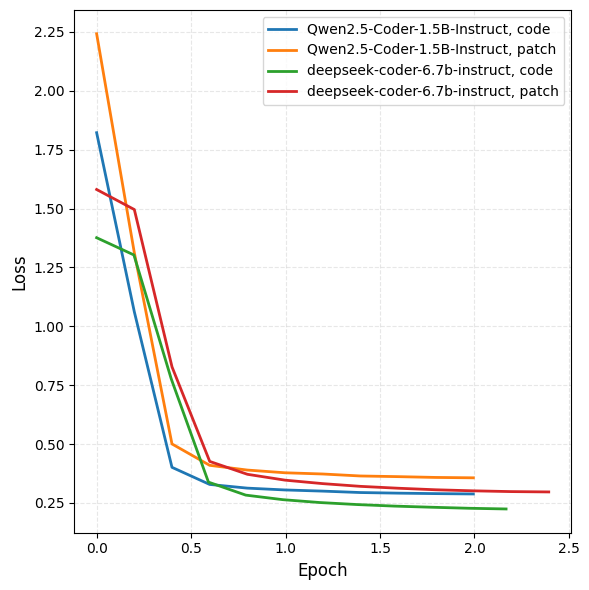

In [19]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

WORK_DIR = Path.cwd()

models = [
    "Qwen2.5-Coder-1.5B-Instruct",
    "deepseek-coder-6.7b-instruct",
]

plt.figure(figsize=(6, 6))

for model in models:
    for type in ["code", "patch"]:
        results_path = (
            WORK_DIR
            / "results"
            / "training"
            / model
            / type
            / "training_logs.json"
        )

        if not results_path.exists():
            print(f"Skipping {model}: file not found")
            continue

        with open(results_path) as f:
            train_results = json.load(f)

        losses, epochs = [], []
        tr_losses, tr_epochs = [], []

        for result in train_results:
            tr_loss = result.get("loss", None)
            if tr_loss:
                tr_epoch = result.get("epoch")
                tr_losses.append(tr_loss)
                tr_epochs.append(tr_epoch)
            
            loss = result.get("eval_loss")
            epoch = result.get("epoch")
            if loss is None or epoch is None:
                continue

            losses.append(loss)
            epochs.append(epoch)

        if not losses:
            print(f"Skipping {model}: no eval_loss found")
            continue

        plt.plot(epochs, losses, marker='', linewidth=2, markersize=4, label=f"{model}, {type}")
        #plt.plot(tr_epochs, tr_losses, marker='', linewidth=2, markersize=4, label=f"{model}, {type}")

plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
#plt.title("Evaluation Loss over Training Epochs", fontsize=14, fontweight="bold")
plt.grid(True, alpha=0.3, linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()
